## **ASSIGNMENT_1**


#Question_10

Question_10(a)

In [ ]:
import pandas as pd
import numpy as np


prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],  # Stock A
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]   # Stock B
])
# Return formula: (P_t - P_t-1) / P_t-1

returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1] # For P_t : sliced from 1 to n-1, and for P_t-1 : sliced from 0 to n-2
print(returns)


[[ 0.08       -0.0462963   0.11650485 -0.04347826  0.08181818  0.05042017
  -0.032       0.07438017 -0.02307692  0.06299213  0.03703704]
 [-0.025       0.07692308 -0.02380952  0.07317073 -0.02272727  0.04651163
   0.02222222 -0.03478261  0.05855856  0.0212766  -0.00833333]]


Question_10(b)

In [ ]:
# Compute monthly metrics across columns for each stock row
monthly_mean = np.mean(returns, axis=1)
monthly_std = np.std(returns, axis=1)

# Annualise the metrics
annualised_mean = monthly_mean * 12
annualised_std = monthly_std * np.sqrt(12)

print("Annualised Mean :", annualised_mean)
print("Annualised Std deviation:", annualised_std)

Annualised Mean : [0.39087388 0.20073826]
Annualised Std deviation: [0.19259375 0.13903413]


Question_10(c)

In [ ]:

cov_matrix = np.cov(returns)

print("Covariance Matrix:\n", cov_matrix, "\n")

# Confirming the mathematical relationship:
# Extract standard deviations from the diagonal (variances) of the covariance matrix
sigma_A = np.sqrt(cov_matrix[0, 0])
sigma_B = np.sqrt(cov_matrix[1, 1])

# Calculate correlation matrix using np.corrcoef and extract the off-diagonal element
corr_matrix = np.corrcoef(returns)
rho = corr_matrix[0, 1]

# Calculate the expected covariance
expected_cov = rho * sigma_A * sigma_B

# Compare the off-diagonal entry of cov_matrix with the expected value
actual_cov = cov_matrix[0, 1]

print(f"Off-diagonal from np.cov: {actual_cov}")
print(f"Calculated from rho * stdA * stdB: {expected_cov}")
print("Thus, off diagonal entry equals rho * sigma_A * sigma_B")

Covariance Matrix:
 [[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]] 

Off-diagonal from np.cov: -0.0020642605060094284
Calculated from rho * stdA * stdB: -0.002064260506009429
Thus, off diagonal entry equals rho * sigma_A * sigma_B


#Question_11

Question_11(a)

In [ ]:
mu = np.array([0.15, 0.08, 0.05])
# Covariance matrix computed in Question 6 :
Sigma = np.array([
    [0.0625, 0.0120, 0.0010],
    [0.0120, 0.0144, 0.00096],
    [0.0010, 0.00096, 0.0016]
])

# Equal weights
w = np.array([1/3, 1/3, 1/3])

# Expected Portfolio Return
exp_return_p = w.T @ mu  # or np.dot(w.T, mu)

# Portfolio Variance
var_p = w.T @ Sigma @ w  # or np.dot(w.T, np.dot(Sigma, w))

print(f"Equal-weight Expected Return: {exp_return_p}")
print(f"Equal-weight Variance: {var_p}")

Equal-weight Expected Return: 0.09333333333333332
Equal-weight Variance: 0.011824444444444443


Question_11(b)

In [ ]:
N_simulations = 10000
N_assets = 3

# Generate 10000 weight vectors, each of length 3, summing to 1. Shape: (10000, 3)
weights_sim = np.random.dirichlet(np.ones(N_assets), size=N_simulations)

# Vectorised computation of expected returns
# weights_sim is (10000, 3) and mu is (3,), matrix multiplication yields (10000,)
expected_returns_sim = weights_sim @ mu

# Vectorised computation of portfolio variances
# 1. Multiply weights_sim (10000, 3) by Sigma (3, 3) -> intermediate matrix (10000, 3)
# 2. Multiply each row of the intermediate matrix by the corresponding row in weights_sim
#    and sum across the rows to get the final scalar variance per simulation.
# Note: standard w.T @ Sigma @ w works for 1D arrays, for 2D arrays (batch processing),
# we use element-wise multiplication and sum.
intermediate = weights_sim @ Sigma
variances_sim = np.sum(intermediate * weights_sim, axis=1)

# Convert variance to standard deviation
vols_sim = np.sqrt(variances_sim)

print("Shape of returns array:", expected_returns_sim.shape)
print("Shape of vols array:", vols_sim.shape)

Shape of returns array: (10000,)
Shape of vols array: (10000,)


Question_11(c)

In [ ]:
# Assuming Risk-Free Rate Rf = 4% as defined in earlier questions (like Q7)
Rf = 0.04

# Vectorised Sharpe Ratio calculation for all 10,000 simulations
sharpe_ratios_sim = (expected_returns_sim - Rf) / vols_sim

# Find the index of the maximum Sharpe Ratio
best_idx = np.argmax(sharpe_ratios_sim)

# Extract the optimal metrics and weights using the index
max_sharpe = sharpe_ratios_sim[best_idx]
optimal_weights = weights_sim[best_idx]

print(f"Maximum Sharpe Ratio: {max_sharpe:.4f}")
print(f"Corresponding Weights: [Asset 1: {optimal_weights[0]:.4f}, Asset 2: {optimal_weights[1]:.4f}, Asset 3: {optimal_weights[2]:.4f}]")

Maximum Sharpe Ratio: 0.5053
Corresponding Weights: [Asset 1: 0.2004, Asset 2: 0.1713, Asset 3: 0.6283]


#Question_12

Question_12(a)

In [ ]:

# Define parameters
w1, w2 = 0.6, 0.4
sigma1, sigma2 = 0.20, 0.10

# Create an array of 200 correlation values from -1 to 1
rhos = np.linspace(-1, 1, 200)

# Calculate the constant variance terms
var1_term = (w1 ** 2) * (sigma1 ** 2)
var2_term = (w2 ** 2) * (sigma2 ** 2)

# Calculate the covariance term multiplier
cov_multiplier = 2 * w1 * w2 * sigma1 * sigma2

# Vectorised computation of portfolio variance and standard deviation
# The array 'rhos' broadcasts the operation to return a (200,) array
port_variances = var1_term + var2_term + (cov_multiplier * rhos)
port_vols = np.sqrt(port_variances)

print("Shape of portfolio volatilities array:", port_vols.shape)

Shape of portfolio volatilities array: (200,)


Question_12(b)

In [ ]:
# Find the index of the minimum volatility
min_idx = np.argmin(port_vols)

# Extract the corresponding correlation and minimum volatility
min_rho = rhos[min_idx]
min_vol = port_vols[min_idx]

print(f"Correlation (rho) that minimises risk: {min_rho:.2f}")
print(f"Minimum portfolio risk (sigma_p): {min_vol:.4f} (or {min_vol * 100:.2f}%)")

Correlation (rho) that minimises risk: -1.00
Minimum portfolio risk (sigma_p): 0.0800 (or 8.00%)


#Question_13

Question_13(a)

In [ ]:
np.random.seed(0)
dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)
df = pd.DataFrame(prices_sim, index=dates,
                  columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])



In [ ]:
# Compute weekly simple returns and drop the first NaN row
df_returns = df.pct_change().dropna()

# Print the first 3 rows
print("First 3 rows of weekly returns:")
print(df_returns.head(3))

# Check the shape
print("\nShape of df_returns:", df_returns.shape)

First 3 rows of weekly returns:
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842

Shape of df_returns: (51, 4)


Question_13(b)

In [ ]:
# Generate summary statistics
summary_stats = df_returns.describe()
print(summary_stats)

# Programmatically extract the highest mean and std
highest_mean_asset = summary_stats.loc['mean'].idxmax()
highest_std_asset = summary_stats.loc['std'].idxmax()

print(f"\nAsset with highest mean return: {highest_mean_asset}")
print(f"Asset with highest standard deviation: {highest_std_asset}")

            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.002650  -0.000365   0.009468
75%     0.039082   0.028178   0.009462   0.020051
max     0.098326   0.060309   0.044265   0.050269

Asset with highest mean return: AMZN
Asset with highest standard deviation: AAPL


Question_13(c)

In [ ]:
rf_annual = 0.02
weeks_in_year = 52

# Vectorised Pandas operations
annualised_returns = df_returns.mean() * weeks_in_year
annualised_volatility = df_returns.std() * np.sqrt(weeks_in_year)

# Compute Sharpe Ratios
sharpe_ratios = (annualised_returns - rf_annual) / annualised_volatility

print("Annualised Sharpe Ratios:")
print(sharpe_ratios)

Annualised Sharpe Ratios:
AAPL     0.824485
MSFT     0.397113
GOOGL   -0.537553
AMZN     1.794045
dtype: float64


#Question_14

Question_14(a)

In [ ]:
# Compute correlation matrix
corr_matrix = df_returns.corr()
print("Correlation Matrix:")
print(corr_matrix)

# To find the lowest pair programmatically (ignoring the diagonal 1.0s):
# We can unstack, drop self-correlations, and find the minimum
stacked_corr = corr_matrix.unstack()
lowest_corr_pair = stacked_corr[stacked_corr < 1.0].idxmin()
lowest_corr_value = stacked_corr.min()

print(f"\nLowest correlation is between: {lowest_corr_pair} (Value: {lowest_corr_value:.4f})")

Correlation Matrix:
           AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000

Lowest correlation is between: ('AAPL', 'MSFT') (Value: -0.0753)


Question_14(b)

In [ ]:
# Create the weights Series
weights = pd.Series([0.25, 0.25, 0.25, 0.25], index=df_returns.columns)

# Calculate portfolio returns
port_returns = df_returns.dot(weights)

print("Equal-weight portfolio returns (first 5 weeks):")
print(port_returns.head())

Equal-weight portfolio returns (first 5 weeks):
2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
2023-01-30    0.011504
2023-02-06   -0.019069
Freq: W-MON, dtype: float64


Question_14(c)

In [ ]:
# Aggregate weekly returns into monthly returns
# 'ME' stands for Month End frequency
monthly_port_returns = port_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)

# Compute mean and standard deviation
monthly_mean = monthly_port_returns.mean()
monthly_std = monthly_port_returns.std()

print("Monthly Portfolio Return Series:")
print(monthly_port_returns.head())
print(f"\nMonthly Mean Return: {monthly_mean:.6f}")
print(f"Monthly Standard Deviation: {monthly_std:.6f}")

Monthly Portfolio Return Series:
2023-01-31    0.058185
2023-02-28    0.001390
2023-03-31   -0.022310
2023-04-30   -0.036822
2023-05-31    0.011764
Freq: ME, dtype: float64

Monthly Mean Return: 0.013975
Monthly Standard Deviation: 0.039023


#Question_15

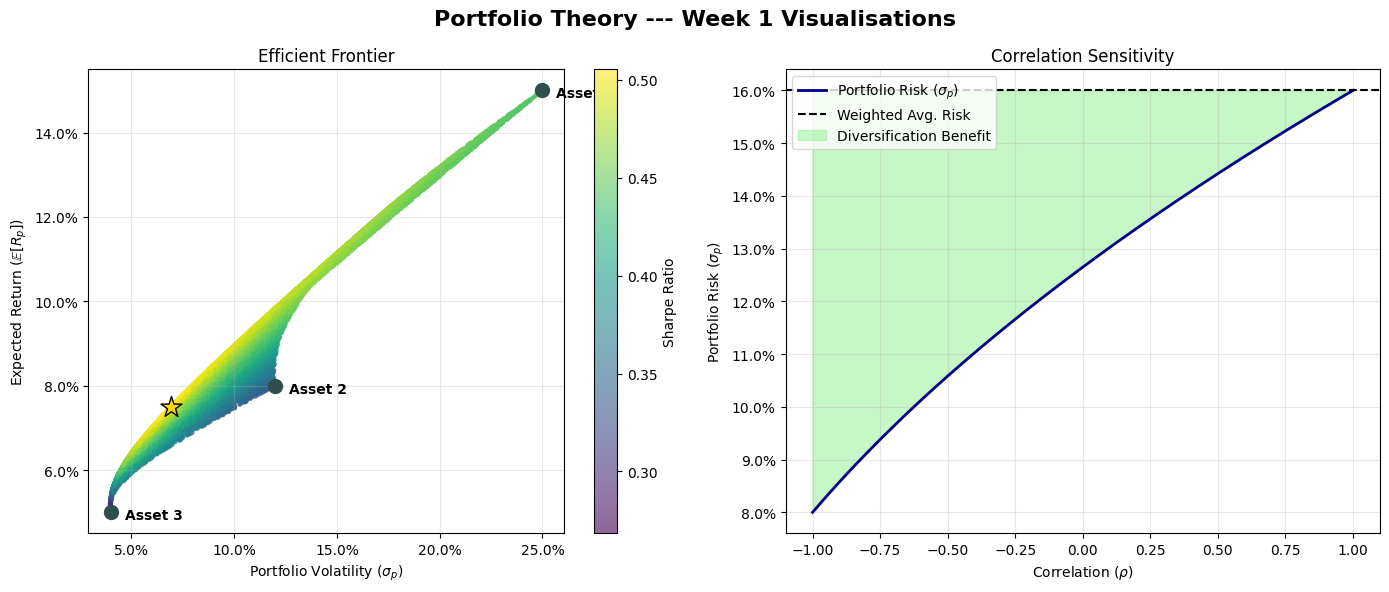

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ---------------------------------------------------------
# Setup Data from Previous Questions
# ---------------------------------------------------------

# Question 11 / Question 6 Data (3-Asset Universe)
mu_3 = np.array([0.15, 0.08, 0.05])
Sigma_3 = np.array([
    [0.0625, 0.0120, 0.0010],
    [0.0120, 0.0144, 0.00096],
    [0.0010, 0.00096, 0.0016]
])
Rf = 0.04  # Risk-free rate (assumed 4% from previous context)

# Question 12 Data (2-Asset Universe)
w1, w2 = 0.6, 0.4
sigma1, sigma2 = 0.20, 0.10

# ---------------------------------------------------------
# Pre-computations for Subplot 1
# ---------------------------------------------------------
np.random.seed(42)  # For reproducibility
n_portfolios = 20000

# Generate 20000 random portfolios
weights_sim = np.random.dirichlet(np.ones(3), size=n_portfolios)
exp_rets_sim = weights_sim @ mu_3

# Vectorised variance calculation for simulated weights
intermediate = weights_sim @ Sigma_3
port_vars_sim = np.sum(intermediate * weights_sim, axis=1)
port_vols_sim = np.sqrt(port_vars_sim)

# Calculate Sharpe Ratios
sharpes_sim = (exp_rets_sim - Rf) / port_vols_sim

# Find Max Sharpe Portfolio
max_idx = np.argmax(sharpes_sim)
max_sharpe_vol = port_vols_sim[max_idx]
max_sharpe_ret = exp_rets_sim[max_idx]

# Extract individual asset standard deviations from the covariance matrix diagonal
asset_vols = np.sqrt(np.diag(Sigma_3))
asset_labels = ['Asset 1', 'Asset 2', 'Asset 3']

# ---------------------------------------------------------
# Pre-computations for Subplot 2
# ---------------------------------------------------------
# 200 equally-spaced points for correlation
rhos = np.linspace(-1, 1, 200)

# Compute portfolio risk across different correlations
var1_term = (w1 ** 2) * (sigma1 ** 2)
var2_term = (w2 ** 2) * (sigma2 ** 2)
cov_mult = 2 * w1 * w2 * sigma1 * sigma2

vols_rho = np.sqrt(var1_term + var2_term + (cov_mult * rhos))
weighted_avg_risk = (w1 * sigma1) + (w2 * sigma2)

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
# Global requirements
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Portfolio Theory --- Week 1 Visualisations', fontsize=16, fontweight='bold')

# --- Subplot 1: Efficient Frontier scatter ---
ax1 = axes[0]

# (a) Scatter plot of 20000 portfolios
sc = ax1.scatter(port_vols_sim, exp_rets_sim, c=sharpes_sim, cmap='viridis',
                 s=5, alpha=0.6, zorder=1)

# (b) Mark the max Sharpe portfolio
ax1.scatter(max_sharpe_vol, max_sharpe_ret, color='gold', marker='*',
            s=250, edgecolor='black', zorder=3, label='Max Sharpe')

# (c) Mark individual assets
ax1.scatter(asset_vols, mu_3, color='darkslategray', s=100, zorder=4)
for i, txt in enumerate(asset_labels):
    ax1.annotate(txt, (asset_vols[i], mu_3[i]), textcoords="offset points",
                 xytext=(10, -5), fontsize=10, fontweight='bold')

# (d) Add colorbar and format axes
cbar = fig.colorbar(sc, ax=ax1)
cbar.set_label('Sharpe Ratio')

ax1.xaxis.set_major_formatter(PercentFormatter(1.0))
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.set_xlabel('Portfolio Volatility ($\\sigma_p$)')
ax1.set_ylabel('Expected Return ($\\mathbb{E}[R_p]$)')
ax1.set_title('Efficient Frontier')
ax1.grid(True, alpha=0.3)


# --- Subplot 2: Correlation Sensitivity ---
ax2 = axes[1]

# (a) Plot portfolio risk vs correlation
ax2.plot(rhos, vols_rho, color='darkblue', lw=2, label='Portfolio Risk ($\\sigma_p$)')

# (b) Add horizontal dashed line for weighted-average risk
ax2.axhline(weighted_avg_risk, color='black', linestyle='--',
            label='Weighted Avg. Risk')

# (c) Shade the diversification benefit region
ax2.fill_between(rhos, vols_rho, weighted_avg_risk,
                 where=(vols_rho < weighted_avg_risk),
                 color='lightgreen', alpha=0.5, label='Diversification Benefit')

# Format Subplot 2
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_xlabel('Correlation ($\\rho$)')
ax2.set_ylabel('Portfolio Risk ($\\sigma_p$)')
ax2.set_title('Correlation Sensitivity')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Global final adjustments and saving
plt.tight_layout()
plt.savefig('week1_plots.png', dpi=150)
plt.show()